**Problem Statement**


The organization is facing high employee attrition without any system to predict which employees may leave

Build a Machine Learning model to predict at-risk employees and help HR take preventive actions




*   Identify employees likely to leave
* Analyze factors causing attrition


*    Support HR in decision-making
*  Reduce hiring costs and improve retention






**Import Libraries**

In [115]:
## Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [116]:
#load the dataset
df = pd.read_csv("/content/HR-Employee-Attrition.csv")

In [117]:
df


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


**Remove Unnecessary Columns**

In [118]:
df.drop(['EmployeeCount','EmployeeNumber','Over18','StandardHours'], axis=1, inplace=True)

**Initial Data Check**

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [120]:
df.shape

(1470, 31)

In [121]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


**Data Cleaning and Check**

In [122]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
Gender,0


In [123]:
## Duplicate check

df.duplicated().sum()

np.int64(0)

There is no null values and duplicate values are present in dataset

In [124]:
from pandas.core.arrays import categorical
## Divide the columns based on the data type

categorical_columns = df.select_dtypes(include=["object"])
numerical_columns = df.select_dtypes(exclude=["object"])

In [125]:
categorical_columns

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,No
...,...,...,...,...,...,...,...,...
1465,No,Travel_Frequently,Research & Development,Medical,Male,Laboratory Technician,Married,No
1466,No,Travel_Rarely,Research & Development,Medical,Male,Healthcare Representative,Married,No
1467,No,Travel_Rarely,Research & Development,Life Sciences,Male,Manufacturing Director,Married,Yes
1468,No,Travel_Frequently,Sales,Medical,Male,Sales Executive,Married,No


In [126]:
numerical_columns

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,2,2,94,3,2,4,5993,...,3,1,0,8,0,1,6,4,0,5
1,49,279,8,1,3,61,2,2,2,5130,...,4,4,1,10,3,3,10,7,1,7
2,37,1373,2,2,4,92,2,1,3,2090,...,3,2,0,7,3,3,0,0,0,0
3,33,1392,3,4,4,56,3,1,3,2909,...,3,3,0,8,3,3,8,7,3,0
4,27,591,2,1,1,40,3,1,2,3468,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,3,41,4,2,4,2571,...,3,3,1,17,3,3,5,2,0,3
1466,39,613,6,1,4,42,2,3,1,9991,...,3,1,1,9,5,3,7,7,1,7
1467,27,155,4,3,2,87,4,2,2,6142,...,4,2,1,6,0,3,6,2,0,3
1468,49,1023,2,3,4,63,2,2,2,5390,...,3,4,0,17,3,2,9,6,0,8


In [127]:
for i in categorical_columns:
  print(df[i].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64
Gender
Male      882
Female    588
Name: count, dtype: int64
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64
MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64
OverTime
No     1054
Yes     

**Finding OutLiers**

In [128]:
## Outlier detection

def outlier_detection(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [129]:
for col in numerical_columns:
  df = outlier_detection(df, col)

In [130]:
df.shape


(699, 31)

**Converting the categorical Data into the numerical Data**

In [131]:
categorical_columns

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,No
...,...,...,...,...,...,...,...,...
1465,No,Travel_Frequently,Research & Development,Medical,Male,Laboratory Technician,Married,No
1466,No,Travel_Rarely,Research & Development,Medical,Male,Healthcare Representative,Married,No
1467,No,Travel_Rarely,Research & Development,Life Sciences,Male,Manufacturing Director,Married,Yes
1468,No,Travel_Frequently,Sales,Medical,Male,Sales Executive,Married,No


In [132]:
from sklearn.preprocessing import LabelEncoder


In [133]:
le_d = {}

In [134]:
for col in categorical_columns:
  le = LabelEncoder()
  df[col]=le.fit_transform(df[col])
  le_d[col] = le

In [135]:
le_d

{'Attrition': LabelEncoder(),
 'BusinessTravel': LabelEncoder(),
 'Department': LabelEncoder(),
 'EducationField': LabelEncoder(),
 'Gender': LabelEncoder(),
 'JobRole': LabelEncoder(),
 'MaritalStatus': LabelEncoder(),
 'OverTime': LabelEncoder()}

In [136]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1463,31,0,0,325,1,5,3,3,2,1,...,3,2,0,10,2,3,9,4,1,7
1464,26,0,2,1167,2,5,3,4,4,0,...,3,4,0,5,2,3,4,2,0,0
1465,36,0,1,884,1,23,2,3,3,1,...,3,3,1,17,3,3,5,2,0,3
1468,49,0,1,1023,2,2,3,3,4,1,...,3,4,0,17,3,2,9,6,0,8
1469,34,0,2,628,1,8,3,3,2,1,...,3,1,0,6,3,4,4,3,1,2


**Univariate Analysis**

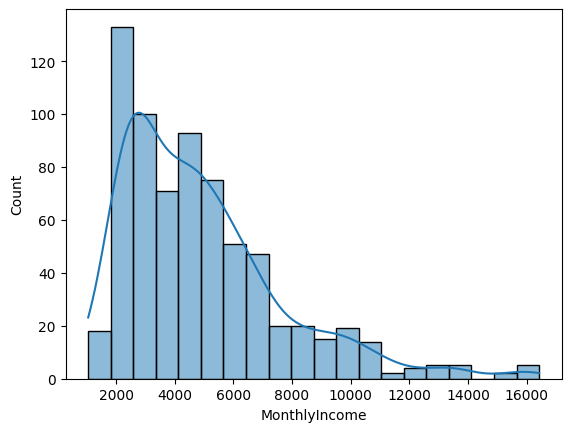

In [137]:


# Example: Monthly Income
sns.histplot(df['MonthlyIncome'], kde=True)
plt.show()

• Most employees fall in mid-income range
• Age is mostly between 25–40
• YearsAtCompany is skewed toward lower values

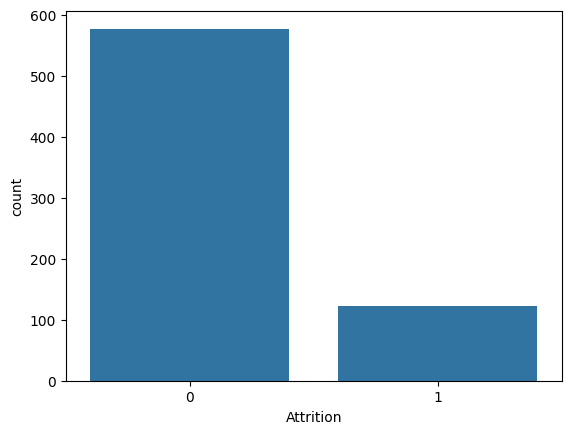

In [138]:
# Count plot
sns.countplot(x='Attrition', data=df)
plt.show()



Majority employees has  No Attrition

**Bivariate Analysis**

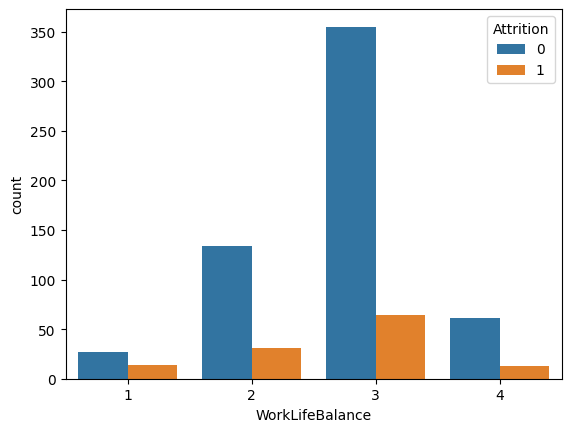

In [139]:
sns.countplot(x='WorkLifeBalance', hue='Attrition', data=df)
plt.show()

Poor the worklife balance then high attrition

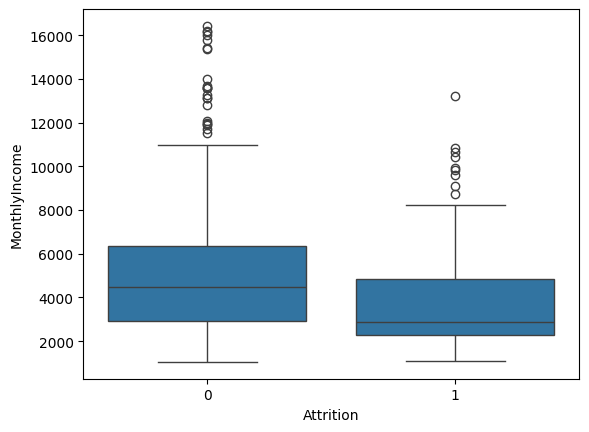

In [140]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.show()

Lower income employees leave more

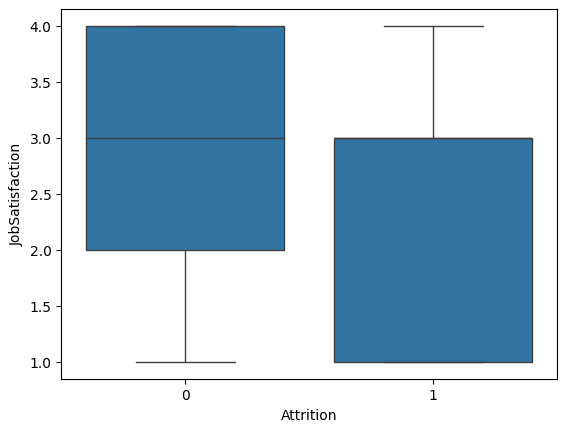

In [141]:
sns.boxplot(x='Attrition', y='JobSatisfaction', data=df)
plt.show()

Low Satisfaction leads to the higher attrition

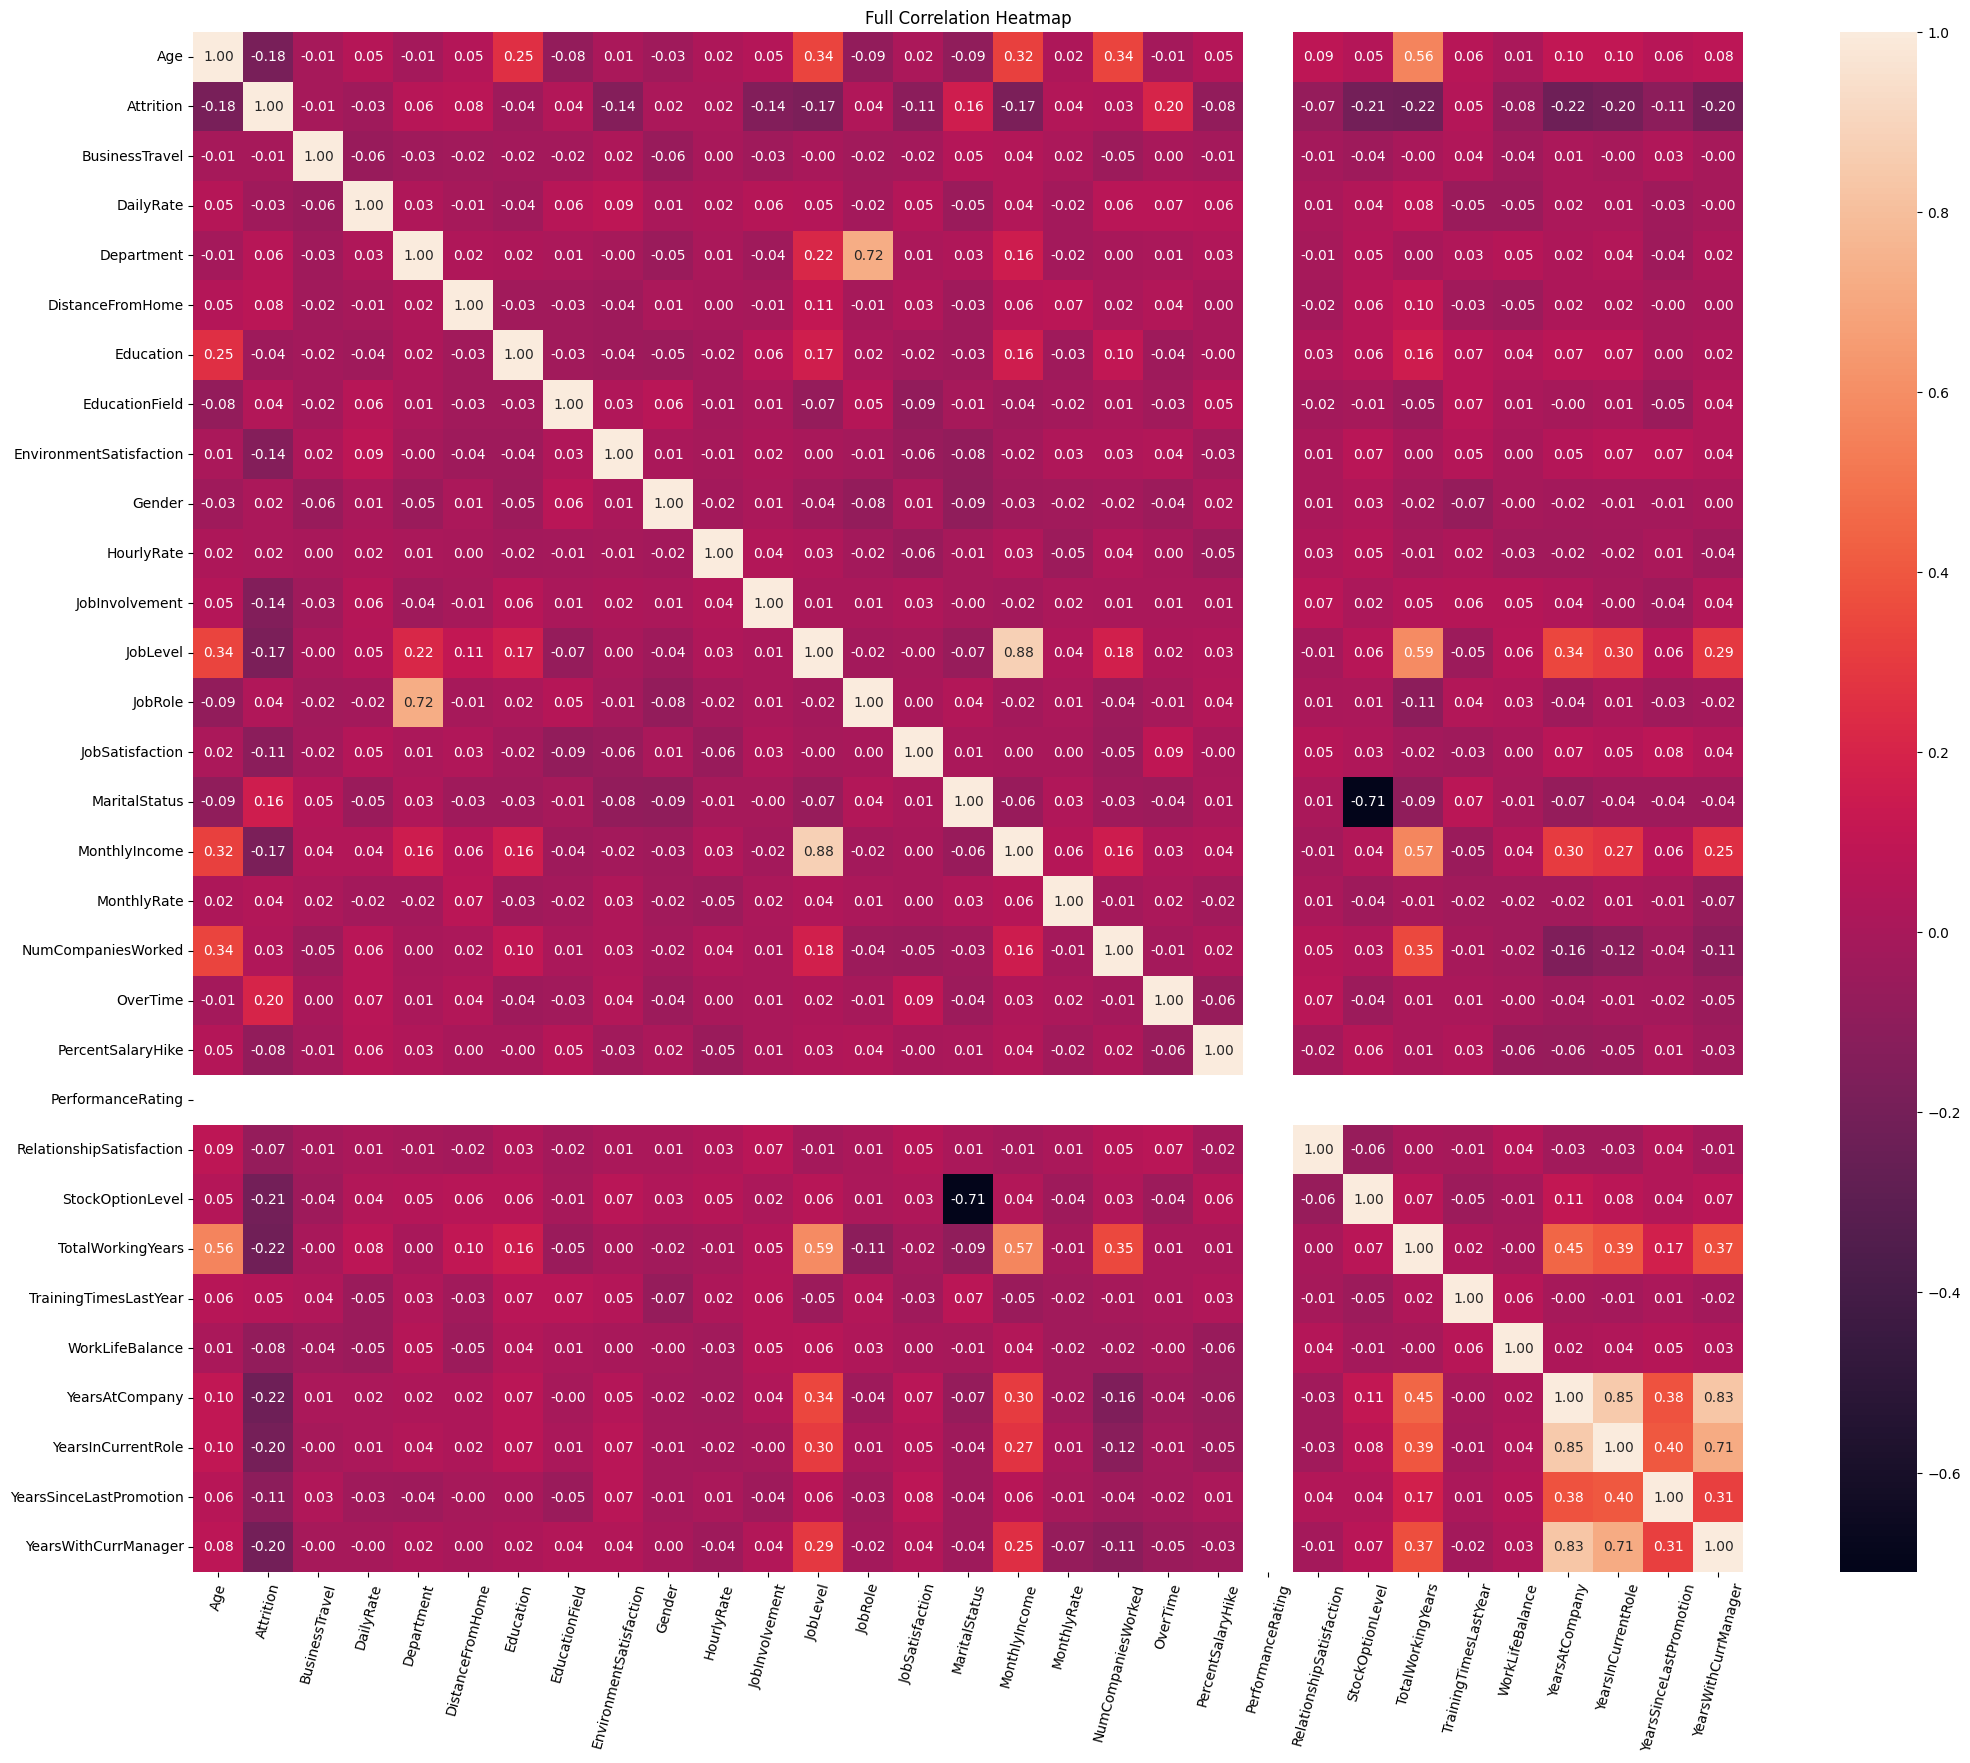

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation for full dataset
corr = df.corr()

# Plot heatmap
plt.figure(figsize=(25,20))
sns.heatmap(corr, annot=True, fmt=".2f")

plt.title("Full Correlation Heatmap")
plt.xticks(rotation=75)
plt.yticks(rotation=0)

plt.show()

The correlation heatmap shows that experience-related features like TotalWorkingYears, YearsAtCompany, and MonthlyIncome have moderate positive relationships. Most other features show weak correlation, indicating low multicollinearity in the dataset. PerformanceRating appears blank because it has almost constant values, so correlation cannot be computed.

**Model Building**

In [143]:
#Divide the dataset in X and y

X=df.drop(columns=["Attrition"],axis = 1)
y=df["Attrition"]

In [144]:
#Divide the dataset into the train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,train_size = 0.7)


In [145]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((489, 30), (210, 30), (489,), (210,))

Initializing the model

In [146]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier


In [147]:
nb = GaussianNB()
lr = LogisticRegression()
rf = RandomForestClassifier()
dt = DecisionTreeClassifier()

In [148]:
#Model Training
nb.fit(X_train,y_train)
lr.fit(X_train,y_train)
rf.fit(X_train,y_train)
dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [149]:
# Model evaluation

nb_pred = nb.predict(X_test)
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
dt_pred = dt.predict(X_test)

In [150]:
# Confusion matrix print for all

print("Confusion matrix for Naive Bayes")
print(metrics.confusion_matrix(y_test, nb_pred))

Confusion matrix for Naive Bayes
[[131  38]
 [  8  33]]


In [151]:
print("Confusion matrix for Linear Model")
print(metrics.confusion_matrix(y_test, lr_pred))

Confusion matrix for Linear Model
[[168   1]
 [ 40   1]]


In [152]:
print("Confusion matrix for Random Forest")
print(metrics.confusion_matrix(y_test, rf_pred))

Confusion matrix for Random Forest
[[169   0]
 [ 36   5]]


In [153]:
print("Confusion matrix for Decision Tree")
print(metrics.confusion_matrix(y_test, dt_pred))

Confusion matrix for Decision Tree
[[144  25]
 [ 23  18]]


In [154]:
nb_acc = metrics.accuracy_score(y_test, nb_pred)
lr_acc = metrics.accuracy_score(y_test, lr_pred)
rf_acc = metrics.accuracy_score(y_test, rf_pred)
dt_acc = metrics.accuracy_score(y_test, dt_pred)

print("Accuracy for Naive Bayes: ", nb_acc)
print("Accuracy for Linear Model: ", lr_acc)
print("Accuracy for Random Forest: ", rf_acc)
print("Accuracy for Decision Tree: ", dt_acc)

Accuracy for Naive Bayes:  0.780952380952381
Accuracy for Linear Model:  0.8047619047619048
Accuracy for Random Forest:  0.8285714285714286
Accuracy for Decision Tree:  0.7714285714285715


In [155]:
best_model = rf

Predict code Data to find the how perform the model

In [156]:
# Apply saved label encoders to categorical columns

# Re-initialize new_data to ensure categorical columns are strings before transformation
new_data = pd.DataFrame({
    'Age': [40],
    'Attrition': ['yes'],
    'BusinessTravel': ['Travel_Rarely'],
    'DailyRate': [950],
    'Department': ['Research & Development'],
    'DistanceFromHome': [7],
    'Education': [3],
    'EducationField': ['Technical Degree'],
    'EmployeeCount': [1],
    'EmployeeNumber': [1101],
    'EnvironmentSatisfaction': [3],
    'Gender': ['Male'],
    'HourlyRate': [60],
    'JobInvolvement': [3],
    'JobLevel': [2],
    'JobRole': ['Research Scientist'],
    'JobSatisfaction': [3],
    'MaritalStatus': ['Married'],
    'MonthlyIncome': [5000],
    'MonthlyRate': [16000],
    'NumCompaniesWorked': [4],
    'Over18': ['Y'],
    'OverTime': ['No'],
    'PercentSalaryHike': [12],
    'PerformanceRating': [3],
    'RelationshipSatisfaction': [3],
    'StandardHours': [80],
    'StockOptionLevel': [1],
    'TotalWorkingYears': [12],
    'TrainingTimesLastYear': [2],
    'WorkLifeBalance': [3],
    'YearsAtCompany': [6],
    'YearsInCurrentRole': [4],
    'YearsSinceLastPromotion': [1],
    'YearsWithCurrManager': [5]
})


In [157]:
new_data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,40,yes,Travel_Rarely,950,Research & Development,7,3,Technical Degree,1,1101,...,3,80,1,12,2,3,6,4,1,5


In [158]:
new_data = new_data.drop(['Attrition','Over18','EmployeeCount','StandardHours','EmployeeNumber'], axis=1, errors='ignore')

In [159]:
new_data

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,40,Travel_Rarely,950,Research & Development,7,3,Technical Degree,3,Male,60,...,3,3,1,12,2,3,6,4,1,5


In [160]:
new_data['BusinessTravel'] = le_d['BusinessTravel'].transform(new_data['BusinessTravel'])
new_data['Department'] = le_d['Department'].transform(new_data['Department'])
new_data['EducationField'] = le_d['EducationField'].transform(new_data['EducationField'])
new_data['Gender'] = le_d['Gender'].transform(new_data['Gender'])
new_data['JobRole'] = le_d['JobRole'].transform(new_data['JobRole'])
new_data['MaritalStatus'] = le_d['MaritalStatus'].transform(new_data['MaritalStatus'])
new_data['OverTime'] = le_d['OverTime'].transform(new_data['OverTime'])

In [161]:
new_data

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,40,2,950,1,7,3,5,3,1,60,...,3,3,1,12,2,3,6,4,1,5


In [162]:
# Predict
prediction = best_model.predict(new_data)

# Output
if prediction[0] == 1:
    print("Employee likely to leave")
else:
    print("Employee will stay")

Employee will stay


In [163]:
prediction

array([0])

In [164]:
## inverse transform to get the final output

print(le_d['Attrition'].inverse_transform(prediction))

['No']
